In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease-data/heart_disease_uci.csv
/kaggle/input/pima-indians-diabetes-database/diabetes.csv
/kaggle/input/breast-cancer-wisconsin-data/data.csv
/kaggle/input/breast-cancer-wisconsin-diagnostic/__results__.html
/kaggle/input/breast-cancer-wisconsin-diagnostic/__resultx__.html
/kaggle/input/breast-cancer-wisconsin-diagnostic/__notebook__.ipynb
/kaggle/input/breast-cancer-wisconsin-diagnostic/__output__.json
/kaggle/input/breast-cancer-wisconsin-diagnostic/custom.css
/kaggle/input/breast-cancer-wisconsin-diagnostic/__results___files/__results___20_1.png
/kaggle/input/breast-cancer-wisconsin-diagnostic/__results___files/__results___31_3.png
/kaggle/input/breast-cancer-wisconsin-diagnostic/__results___files/__results___29_3.png
/kaggle/input/breast-cancer-wisconsin-diagnostic/__results___files/__results___40_0.png
/kaggle/input/breast-cancer-wisconsin-diagnostic/__results___files/__results___31_1.png
/kaggle/input/breast-cancer-wisconsin-diagnostic/__results___files/__r

In [2]:
import os, glob

for folder in os.listdir("/kaggle/input"):
    path = f"/kaggle/input/{folder}"
    files = glob.glob(path + "/**/*", recursive=True)
    files = [f for f in files if os.path.isfile(f)]
    print("\n==", folder, "==")
    for f in files[:50]:
        print(f)



== heart-disease-data ==
/kaggle/input/heart-disease-data/heart_disease_uci.csv

== pima-indians-diabetes-database ==
/kaggle/input/pima-indians-diabetes-database/diabetes.csv

== breast-cancer-wisconsin-data ==
/kaggle/input/breast-cancer-wisconsin-data/data.csv

== breast-cancer-wisconsin-diagnostic ==
/kaggle/input/breast-cancer-wisconsin-diagnostic/__results__.html
/kaggle/input/breast-cancer-wisconsin-diagnostic/__resultx__.html
/kaggle/input/breast-cancer-wisconsin-diagnostic/__notebook__.ipynb
/kaggle/input/breast-cancer-wisconsin-diagnostic/__output__.json
/kaggle/input/breast-cancer-wisconsin-diagnostic/custom.css
/kaggle/input/breast-cancer-wisconsin-diagnostic/__results___files/__results___20_1.png
/kaggle/input/breast-cancer-wisconsin-diagnostic/__results___files/__results___31_3.png
/kaggle/input/breast-cancer-wisconsin-diagnostic/__results___files/__results___29_3.png
/kaggle/input/breast-cancer-wisconsin-diagnostic/__results___files/__results___40_0.png
/kaggle/input/br

=== Loaded Datasets ===
- Pima Diabetes: (768, 9) -> /kaggle/input/pima-indians-diabetes-database/diabetes.csv
- Bank Marketing: (11162, 17) -> /kaggle/input/d/janiobachmann/bank-marketing-dataset/bank.csv
- Heart Disease UCI: (920, 16) -> /kaggle/input/heart-disease-data/heart_disease_uci.csv
- Breast Cancer Wisconsin: (569, 32) -> /kaggle/input/breast-cancer-wisconsin-data/data.csv

=== RESULTS (Mean ± Std) ===
                    Dataset     Target          Model  Accuracy_mean  \
0             Pima Diabetes    Outcome            KNN         0.7278   
1             Pima Diabetes    Outcome      SVM (RBF)         0.7617   
2             Pima Diabetes    Outcome    Naive Bayes         0.7552   
3             Pima Diabetes    Outcome  Decision Tree         0.7004   
4            Bank Marketing    deposit            KNN         0.8026   
5            Bank Marketing    deposit      SVM (RBF)         0.8527   
6            Bank Marketing    deposit    Naive Bayes         0.7188   
7      

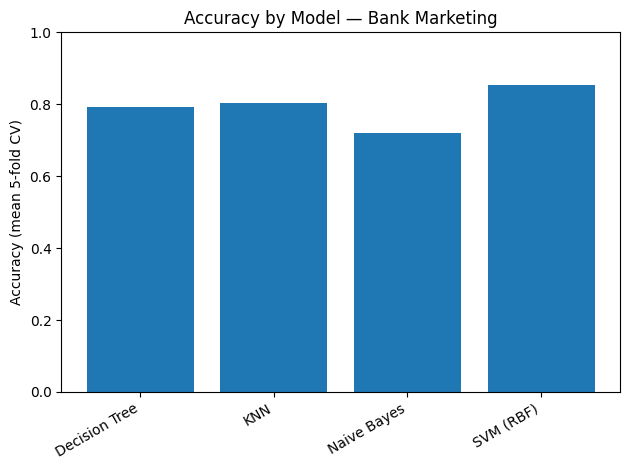

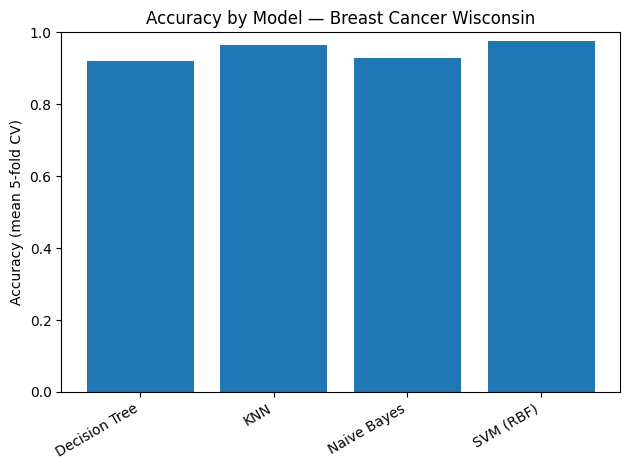

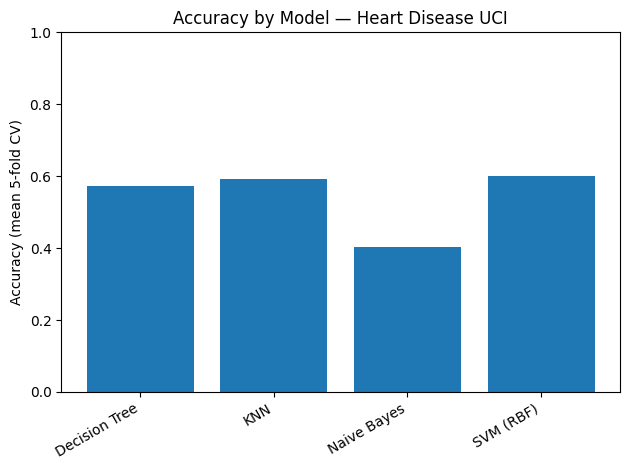

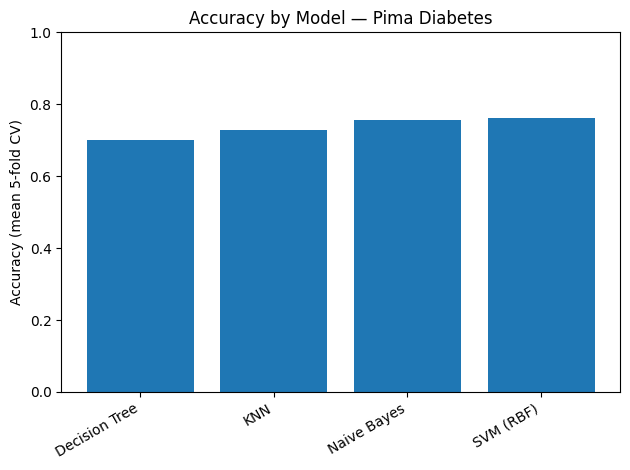

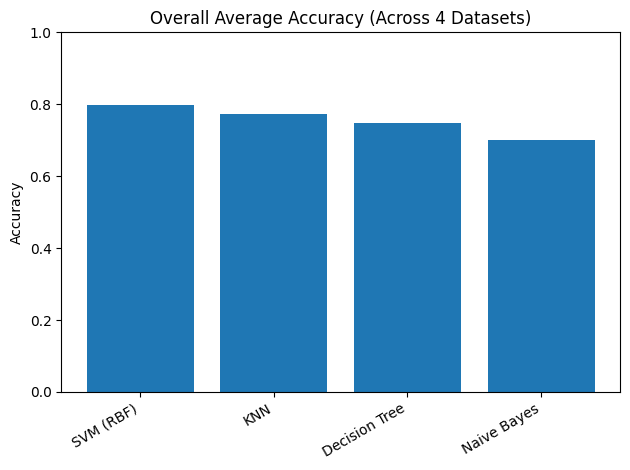

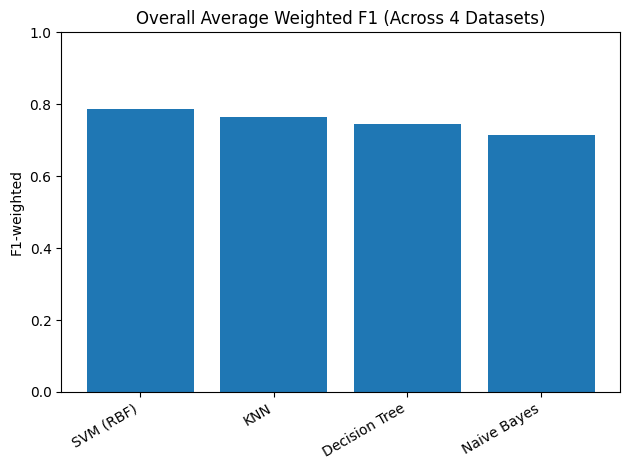

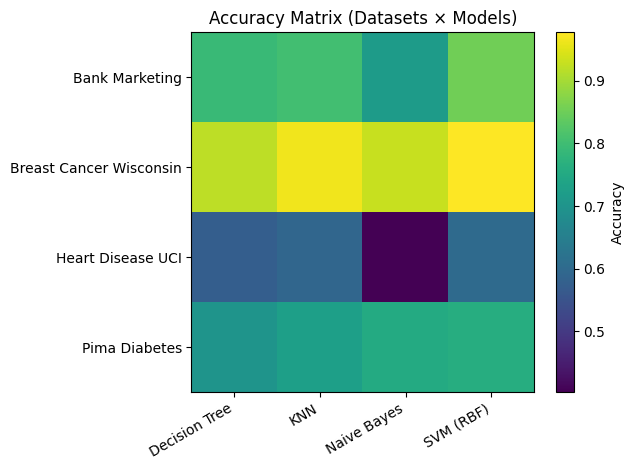


Saved: model_comparison_results.csv


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import make_scorer, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
N_SPLITS = 5


DATASET_CONFIGS = [
    {
        "name": "Pima Diabetes",
        "path": "/kaggle/input/pima-indians-diabetes-database/diabetes.csv",
        "target": "Outcome",
    },
    {
        "name": "Bank Marketing",
        "path": "/kaggle/input/d/janiobachmann/bank-marketing-dataset/bank.csv",
        "target": "y",
    },
    {
        "name": "Heart Disease UCI",
        "path": "/kaggle/input/heart-disease-data/heart_disease_uci.csv",
        "target": "target",   # if this fails, code will auto-fallback
    },
    {
        "name": "Breast Cancer Wisconsin",
        "path": "/kaggle/input/breast-cancer-wisconsin-data/data.csv",
        "target": "diagnosis",
    },
]

def load_df(path):
    df = pd.read_csv(path)
    df = df.loc[:, ~df.columns.str.contains("^Unnamed", case=False)]
    return df

datasets = []
print("=== Loaded Datasets ===")
for ds in DATASET_CONFIGS:
    df = load_df(ds["path"])
    print(f"- {ds['name']}: {df.shape} -> {ds['path']}")
    datasets.append({**ds, "df": df})


MODELS = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, gamma="scale"),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "f1_weighted": make_scorer(f1_score, average="weighted", zero_division=0)
}


def build_preprocessor(X: pd.DataFrame, dense_onehot=False):
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    if dense_onehot:
        cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        cat_encoder = OneHotEncoder(handle_unknown="ignore")

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", cat_encoder)
    ])

    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, numeric_cols),
            ("cat", cat_pipe, categorical_cols)
        ],
        remainder="drop"
    )

def pick_target(df, preferred_target):
    # preferred first
    if preferred_target in df.columns:
        return preferred_target
    # common fallbacks
    for c in ["target", "Outcome", "diagnosis", "y", "label", "class"]:
        if c in df.columns:
            return c
    return df.columns[-1]


def benchmark_one_dataset(df: pd.DataFrame, dataset_name: str, target_col: str):
    # select target safely
    target_col = pick_target(df, target_col)
    y = df[target_col]
    X = df.drop(columns=[target_col])

    # drop missing target rows
    mask = y.notna()
    X = X.loc[mask]
    y = y.loc[mask]

    # encode target if string/categorical
    if y.dtype == "object" or str(y.dtype).startswith("category"):
        y = y.astype("category").cat.codes

    rows = []
    for model_name, model in MODELS.items():
        dense_needed = (model_name == "Naive Bayes")
        prep = build_preprocessor(X, dense_onehot=dense_needed)

        pipe = Pipeline(steps=[("prep", prep), ("model", model)])

        scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)

        rows.append({
            "Dataset": dataset_name,
            "Target": target_col,
            "Model": model_name,
            "Accuracy_mean": scores["test_accuracy"].mean(),
            "Accuracy_std": scores["test_accuracy"].std(),
            "F1_weighted_mean": scores["test_f1_weighted"].mean(),
            "F1_weighted_std": scores["test_f1_weighted"].std(),
        })

    return pd.DataFrame(rows)


all_results = []
for ds in datasets:
    res = benchmark_one_dataset(ds["df"], ds["name"], ds["target"])
    all_results.append(res)

results = pd.concat(all_results, ignore_index=True)

print("\n=== RESULTS (Mean ± Std) ===")
print(results.round(4))


pivot_acc = results.pivot(index="Dataset", columns="Model", values="Accuracy_mean")
pivot_f1  = results.pivot(index="Dataset", columns="Model", values="F1_weighted_mean")

print("\n=== Accuracy Table (Mean) ===")
print(pivot_acc.round(4))

print("\n=== F1 Weighted Table (Mean) ===")
print(pivot_f1.round(4))



# A) Accuracy bar chart per dataset
for dataset in pivot_acc.index:
    plt.figure()
    vals = pivot_acc.loc[dataset].values
    labels = pivot_acc.columns.tolist()
    plt.bar(labels, vals)
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.title(f"Accuracy by Model — {dataset}")
    plt.ylabel("Accuracy (mean 5-fold CV)")
    plt.tight_layout()
    plt.show()

# B) Overall average Accuracy and F1 (across datasets)
avg_acc = results.groupby("Model")["Accuracy_mean"].mean().sort_values(ascending=False)
avg_f1  = results.groupby("Model")["F1_weighted_mean"].mean().sort_values(ascending=False)

plt.figure()
plt.bar(avg_acc.index, avg_acc.values)
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Overall Average Accuracy (Across 4 Datasets)")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(avg_f1.index, avg_f1.values)
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Overall Average Weighted F1 (Across 4 Datasets)")
plt.ylabel("F1-weighted")
plt.tight_layout()
plt.show()

# C) Accuracy matrix heatmap-style plot
plt.figure()
plt.imshow(pivot_acc.values, aspect="auto")
plt.xticks(range(len(pivot_acc.columns)), pivot_acc.columns, rotation=30, ha="right")
plt.yticks(range(len(pivot_acc.index)), pivot_acc.index)
plt.title("Accuracy Matrix (Datasets × Models)")
plt.colorbar(label="Accuracy")
plt.tight_layout()
plt.show()


results.to_csv("model_comparison_results.csv", index=False)
print("\nSaved: model_comparison_results.csv")
